# mama-sante — EDA on synthetic bootstrap data
Goal: verify the synthetic patients/centers are usable for training the risk stratifier while real Malian data is being collected.
Data generated by `scripts/generate_synthetic_data.py`.

In [1]:
import os, sys
ROOT = os.getcwd()
if not os.path.exists(os.path.join(ROOT, "data", "raw", "patients.csv")) and os.path.basename(ROOT) == "notebooks":
    ROOT = os.path.dirname(ROOT)
os.chdir(ROOT)
sys.path.insert(0, ROOT)
print("working dir:", ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

working dir: /home/kone/BIO_Projects/Projects/machINE_ML


In [2]:
patients = pd.read_csv("data/raw/patients.csv")
centers = pd.read_csv("data/geo/centers.csv")
print(patients.shape, centers.shape)

(2000, 10) (12, 8)


In [3]:
patients.info()
patients.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               2000 non-null   object 
 1   age                      2000 non-null   int64  
 2   rural_flag               2000 non-null   int64  
 3   wealth_quartile          2000 non-null   int64  
 4   family_history           2000 non-null   int64  
 5   prior_biopsy             2000 non-null   int64  
 6   palpability              2000 non-null   int64  
 7   symptom_duration_months  2000 non-null   float64
 8   region                   2000 non-null   object 
 9   label                    2000 non-null   int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 156.4+ KB


,patient_id,age,rural_flag,wealth_quartile,family_history,prior_biopsy,palpability,symptom_duration_months,region,label
0,ML-000001,52,1,3,1,1,0,6.900,Koulikoro,1
1,ML-000002,36,1,2,0,0,0,0.800,Mopti,0
2,ML-000003,57,1,3,0,0,0,1.900,Kidal,0
3,ML-000004,59,1,1,0,0,1,2.300,Segou,0
4,ML-000005,25,1,2,1,0,0,0.600,Nioro du Sahel,0


In [4]:
patients.describe()

,age,rural_flag,wealth_quartile,family_history,prior_biopsy,palpability,symptom_duration_months,label
count,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000
mean,47.373,0.560,2.496,0.112,0.053,0.148,4.023,0.066
std,11.953,0.496,1.105,0.315,0.224,0.356,4.048,0.248
min,18.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000
25%,39.000,0.000,2.000,0.000,0.000,0.000,1.100,0.000
50%,48.000,1.000,3.000,0.000,0.000,0.000,2.800,0.000
75%,55.000,1.000,3.000,0.000,0.000,0.000,5.700,0.000
max,85.000,1.000,4.000,1.000,1.000,1.000,38.200,1.000


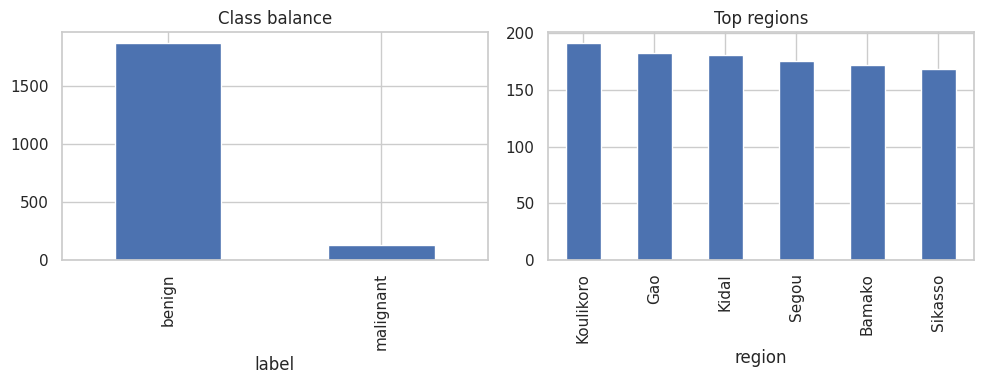

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
patients["label"].map({0: "benign", 1: "malignant"}).value_counts().plot.bar(ax=ax[0])
ax[0].set_title("Class balance")
patients["region"].value_counts().head(6).plot.bar(ax=ax[1])
ax[1].set_title("Top regions")
plt.tight_layout()

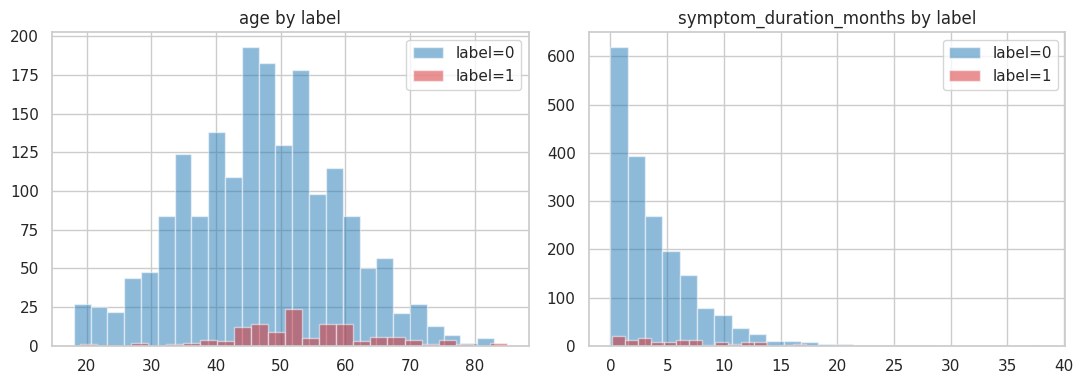

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["age", "symptom_duration_months"]):
    for lab, color in [(0, "tab:blue"), (1, "tab:red")]:
        patients.loc[patients["label"] == lab, col].hist(alpha=0.5, label=f"label={lab}", bins=25, ax=ax, color=color)
    ax.set_title(f"{col} by label")
    ax.legend()
plt.tight_layout()

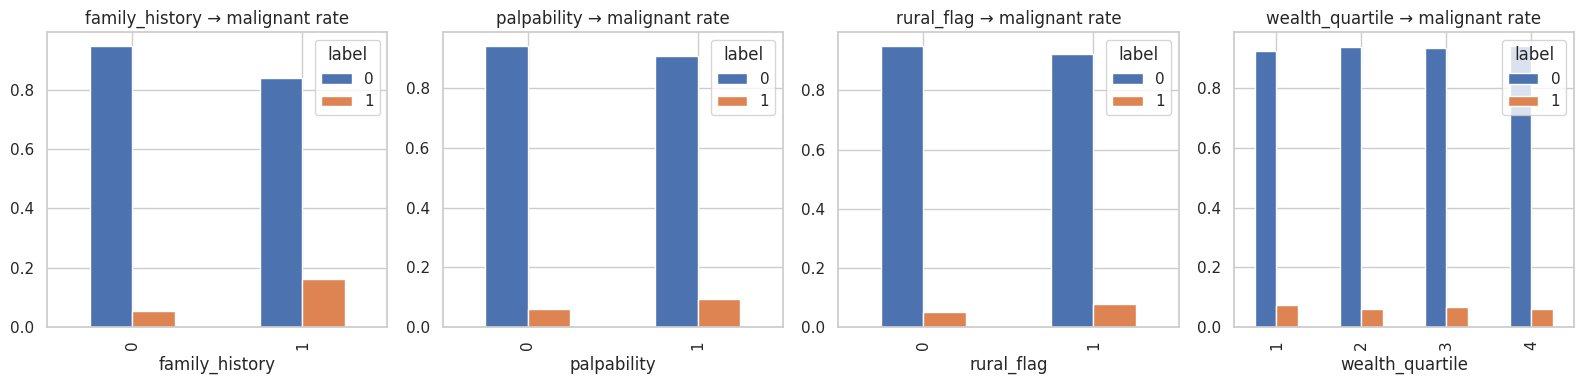

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ["family_history", "palpability", "rural_flag", "wealth_quartile"]):
    pd.crosstab(patients[col], patients["label"], normalize="index").plot.bar(ax=ax)
    ax.set_title(f"{col} → malignant rate")
plt.tight_layout()

Text(0.5, 1.0, 'Feature correlation')

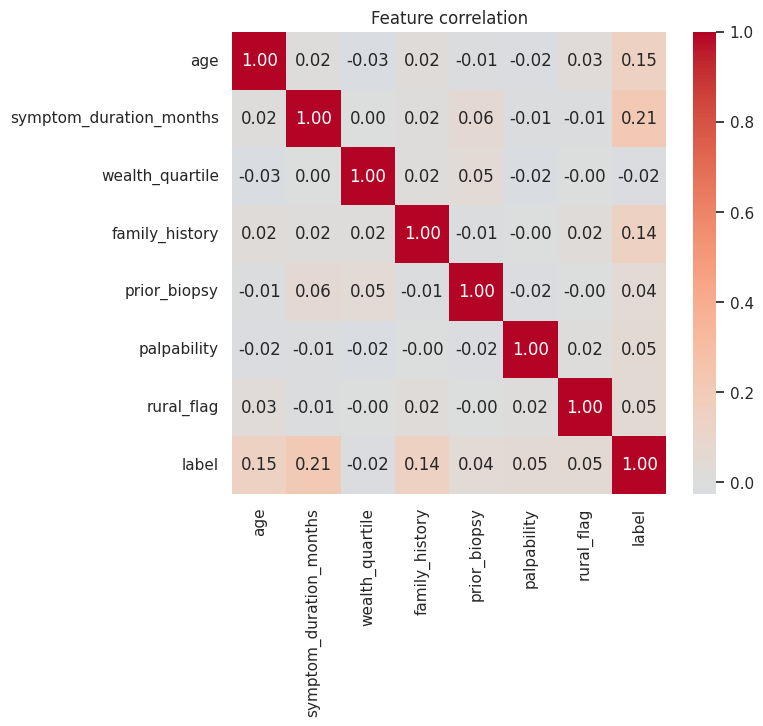

In [8]:
num = patients[["age", "symptom_duration_months", "wealth_quartile",
                "family_history", "prior_biopsy", "palpability", "rural_flag", "label"]]
plt.figure(figsize=(7, 6))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation")

Text(0, 0.5, 'lat')

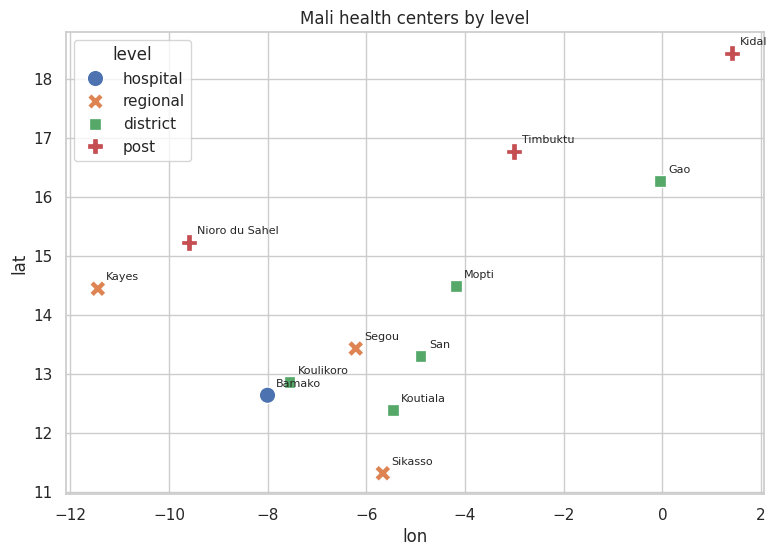

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=centers, x="lon", y="lat", hue="level", style="level", s=140, ax=ax)
for _, c in centers.iterrows():
    ax.annotate(c["name"], (c["lon"], c["lat"]), textcoords="offset points", xytext=(6, 6), fontsize=8)
ax.set_title("Mali health centers by level")
ax.set_xlabel("lon"); ax.set_ylabel("lat")

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

features = ["age", "symptom_duration_months", "wealth_quartile",
            "family_history", "prior_biopsy", "palpability", "rural_flag"]
X, y = patients[features], patients["label"]
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))
scores = cross_val_score(model, X, y, cv=StratifiedKFold(5), scoring="roc_auc")
print(f"5-fold CV AUC: {scores.mean():.3f} ± {scores.std():.3f}")

5-fold CV AUC: 0.773 ± 0.030


## Next steps
- Add simulated scan crops to `data/images/` and train the imaging CNN on real public datasets (e.g. BUSI) via transfer learning.
- Wire `/triage` to the fitted stratifier + imaging model.
- Add road-network routing with OSMnx once real clinic locations are confirmed.